In [ ]:
from google.colab import files
uploaded = files.upload()  # upload 'clean_listings_32827.csv'

Saving rentcast_32789_properties.csv to rentcast_32789_properties.csv
Saving rentcast_32801_properties.csv to rentcast_32801_properties.csv
Saving rentcast_32803_properties.csv to rentcast_32803_properties.csv
Saving rentcast_32804_properties.csv to rentcast_32804_properties.csv
Saving rentcast_32805_properties.csv to rentcast_32805_properties.csv
Saving rentcast_32806_properties.csv to rentcast_32806_properties.csv
Saving rentcast_32812_properties.csv to rentcast_32812_properties.csv
Saving rentcast_32819_properties.csv to rentcast_32819_properties.csv
Saving rentcast_32822_properties.csv to rentcast_32822_properties.csv
Saving rentcast_32827_properties.csv to rentcast_32827_properties.csv


In [ ]:
!ls

drive			       rentcast_32806_properties.csv
rentcast_32789_properties.csv  rentcast_32812_properties.csv
rentcast_32801_properties.csv  rentcast_32819_properties.csv
rentcast_32803_properties.csv  rentcast_32822_properties.csv
rentcast_32804_properties.csv  rentcast_32827_properties.csv
rentcast_32805_properties.csv  sample_data


In [ ]:
import pandas as pd
import glob

# List your files (or use glob to grab them dynamically)
csv_files = glob.glob("rentcast_*.csv")

# Columns you want to keep
relevant_cols = ['formattedAddress', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'squareFootage', 'propertyType']

# Load, clean, and store in a list
cleaned_dfs = []

for file in csv_files:
    df = pd.read_csv(file)

    # Keep only the relevant columns that exist
    available_cols = [col for col in relevant_cols if col in df.columns]
    df = df[available_cols].copy()

    # Add zip code from file name
    zip_code = file.split('_')[1]  # e.g., "32827"
    df['zipCode'] = zip_code

    # Drop rows with any missing required fields
    df = df.dropna(subset=['latitude', 'longitude', 'bedrooms', 'bathrooms', 'squareFootage', 'propertyType'])

    cleaned_dfs.append(df)

# Combine all into a single pool
evaluation_pool = pd.concat(cleaned_dfs, ignore_index=True)

# Preview result
print(f"Final evaluation pool size: {len(evaluation_pool)}")
print(evaluation_pool.head())



Final evaluation pool size: 26241
                                 formattedAddress   latitude  longitude  \
0         1769 Indiana Ave, Winter Park, FL 32789  28.586768 -81.372879   
1   832 Symonds Ave, Apt 6, Winter Park, FL 32789  28.598691 -81.360010   
2           2234 Howard Dr, Winter Park, FL 32789  28.574262 -81.341051   
3        2036 Via, Tuscany, Winter Park, FL 32789  28.617215 -81.338953   
4  1500 Michigan Ave Apt B, Winter Park, FL 32789  28.588411 -81.369227   

   bedrooms  bathrooms  squareFootage   propertyType zipCode  
0       3.0        2.5         1616.0      Townhouse   32789  
1       2.0        1.0          550.0      Apartment   32789  
2       4.0        5.0         3295.0  Single Family   32789  
3       3.0        2.0         2148.0  Single Family   32789  
4       4.0        4.0         2520.0   Multi-Family   32789  


In [ ]:
# Filter evaluation pool
valid_types = ['Single Family', 'Condo', 'Townhouse', 'Multi-Family', 'Apartment']
evaluation_pool = evaluation_pool[evaluation_pool['propertyType'].isin(valid_types)].copy()
print(evaluation_pool.head())


                                 formattedAddress   latitude  longitude  \
0         1769 Indiana Ave, Winter Park, FL 32789  28.586768 -81.372879   
1   832 Symonds Ave, Apt 6, Winter Park, FL 32789  28.598691 -81.360010   
2           2234 Howard Dr, Winter Park, FL 32789  28.574262 -81.341051   
3        2036 Via, Tuscany, Winter Park, FL 32789  28.617215 -81.338953   
4  1500 Michigan Ave Apt B, Winter Park, FL 32789  28.588411 -81.369227   

   bedrooms  bathrooms  squareFootage   propertyType zipCode  
0       3.0        2.5         1616.0      Townhouse   32789  
1       2.0        1.0          550.0      Apartment   32789  
2       4.0        5.0         3295.0  Single Family   32789  
3       3.0        2.0         2148.0  Single Family   32789  
4       4.0        4.0         2520.0   Multi-Family   32789  


In [ ]:
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 1. Check for missing values in any column
missing_summary = evaluation_pool.isnull().sum()
print("Missing values per column:\n", missing_summary[missing_summary > 0])

if missing_summary.sum() == 0:
    print("✅ No missing values in the evaluation pool.")

# 2. Display top rows
print("\nHead of the DataFrame:")
print(evaluation_pool.head())

from sklearn.cluster import KMeans
import numpy as np

sampled_dfs = []

for zip_code, group in evaluation_pool.groupby('zipCode'):
    if len(group) < 50:
        print(f"⚠️ Not enough samples in {zip_code}, using all {len(group)} rows.")
        sampled_dfs.append(group)
        continue

    # Normalize features for clustering
    features = group[['bedrooms', 'bathrooms', 'squareFootage']].copy()
    features = (features - features.mean()) / features.std()

    # KMeans clustering
    kmeans = KMeans(n_clusters=50, random_state=42)
    group['cluster'] = kmeans.fit_predict(features)

    # Take one representative per cluster
    cluster_sample = group.groupby('cluster').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)
    sampled_dfs.append(cluster_sample)

# Combine all zip code samples into one DataFrame
sampled_properties = pd.concat(sampled_dfs, ignore_index=True)

# Preview
print(f"Final sampled dataset has {len(sampled_properties)} rows.")
print(sampled_properties.head())


Missing values per column:
 Series([], dtype: int64)
✅ No missing values in the evaluation pool.

Head of the DataFrame:
                                 formattedAddress   latitude  longitude  \
0         1769 Indiana Ave, Winter Park, FL 32789  28.586768 -81.372879   
1   832 Symonds Ave, Apt 6, Winter Park, FL 32789  28.598691 -81.360010   
2           2234 Howard Dr, Winter Park, FL 32789  28.574262 -81.341051   
3        2036 Via, Tuscany, Winter Park, FL 32789  28.617215 -81.338953   
4  1500 Michigan Ave Apt B, Winter Park, FL 32789  28.588411 -81.369227   

   bedrooms  bathrooms  squareFootage   propertyType zipCode  
0       3.0        2.5         1616.0      Townhouse   32789  
1       2.0        1.0          550.0      Apartment   32789  
2       4.0        5.0         3295.0  Single Family   32789  
3       3.0        2.0         2148.0  Single Family   32789  
4       4.0        4.0         2520.0   Multi-Family   32789  


<ipython-input-28-86729006249c>:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_sample = group.groupby('cluster').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)
<ipython-input-28-86729006249c>:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_sample = group.groupby('cluster').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)
<ipython-input-28-867290

Final sampled dataset has 500 rows.
                                 formattedAddress   latitude  longitude  \
0        2016 Killarney Dr, Winter Park, FL 32789  28.596441 -81.377013   
1         450 W Canton Ave, Winter Park, FL 32789  28.600163 -81.355706   
2         510 W Swoope Ave, Winter Park, FL 32789  28.601525 -81.356153   
3  700 Melrose Ave, Apt M3, Winter Park, FL 32789  28.586997 -81.359511   
4            313 N Knowles, Winter Park, FL 32789  28.599795 -81.350173   

   bedrooms  bathrooms  squareFootage   propertyType zipCode  cluster  
0       1.0        1.0          632.0  Single Family   32789        0  
1       3.0        2.0         1782.0  Single Family   32789        1  
2       4.0        3.5         4130.0      Townhouse   32789        2  
3       2.0        2.0         1074.0          Condo   32789        3  
4       1.0        1.0        24561.0      Apartment   32789        4  


<ipython-input-28-86729006249c>:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_sample = group.groupby('cluster').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)


In [ ]:
print(f"Final sampled dataset has {len(sampled_properties)} rows.")
print(sampled_properties.head())


Final sampled dataset has 500 rows.
                                 formattedAddress   latitude  longitude  \
0        2016 Killarney Dr, Winter Park, FL 32789  28.596441 -81.377013   
1         450 W Canton Ave, Winter Park, FL 32789  28.600163 -81.355706   
2         510 W Swoope Ave, Winter Park, FL 32789  28.601525 -81.356153   
3  700 Melrose Ave, Apt M3, Winter Park, FL 32789  28.586997 -81.359511   
4            313 N Knowles, Winter Park, FL 32789  28.599795 -81.350173   

   bedrooms  bathrooms  squareFootage   propertyType zipCode  cluster  
0       1.0        1.0          632.0  Single Family   32789        0  
1       3.0        2.0         1782.0  Single Family   32789        1  
2       4.0        3.5         4130.0      Townhouse   32789        2  
3       2.0        2.0         1074.0          Condo   32789        3  
4       1.0        1.0        24561.0      Apartment   32789        4  


Properties per zip code:
zipCode
32789    50
32801    50
32803    50
32804    50
32805    50
32806    50
32812    50
32819    50
32822    50
32827    50
Name: count, dtype: int64
📊 Feature Summary (min, max, mean, std):

         bedrooms   bathrooms  squareFootage
count  500.000000  500.000000     500.000000
mean     3.780000    3.028000    6259.854000
std      3.765097    3.034573   46769.667665
min      0.000000    1.000000     228.000000
25%      2.000000    2.000000    1321.500000
50%      3.000000    2.500000    2242.000000
75%      4.000000    4.000000    3456.250000
max     61.000000   52.000000  996981.000000

🏠 Property Type Distribution:

propertyType
Single Family    311
Condo             62
Apartment         60
Multi-Family      53
Townhouse         14
Name: count, dtype: int64


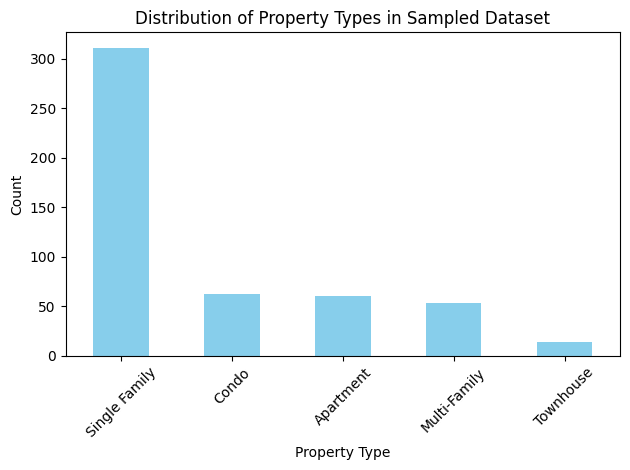

                                 formattedAddress   latitude  longitude  \
0        2016 Killarney Dr, Winter Park, FL 32789  28.596441 -81.377013   
1         450 W Canton Ave, Winter Park, FL 32789  28.600163 -81.355706   
2         510 W Swoope Ave, Winter Park, FL 32789  28.601525 -81.356153   
3  700 Melrose Ave, Apt M3, Winter Park, FL 32789  28.586997 -81.359511   
4            313 N Knowles, Winter Park, FL 32789  28.599795 -81.350173   

   bedrooms  bathrooms  squareFootage   propertyType zipCode  cluster  
0       1.0        1.0          632.0  Single Family   32789        0  
1       3.0        2.0         1782.0  Single Family   32789        1  
2       4.0        3.5         4130.0      Townhouse   32789        2  
3       2.0        2.0         1074.0          Condo   32789        3  
4       1.0        1.0        24561.0      Apartment   32789        4  


In [ ]:
# Count of properties per zip code
print("Properties per zip code:")
print(sampled_properties['zipCode'].value_counts().sort_index())

# Numerical feature stats
print("📊 Feature Summary (min, max, mean, std):\n")
print(sampled_properties[['bedrooms', 'bathrooms', 'squareFootage']].describe())

# Property type distribution
print("\n🏠 Property Type Distribution:\n")
print(sampled_properties['propertyType'].value_counts())

# Optional: bar plot for better visualization
import matplotlib.pyplot as plt

sampled_properties['propertyType'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Property Types in Sampled Dataset")
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(sampled_properties.head())
sampled_properties.to_csv('/content/drive/MyDrive/sampled_properties.csv', index=False)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving sampled_properties.csv to sampled_properties.csv


In [7]:
!ls

sample_data  sampled_properties.csv


In [9]:
df = pd.read_csv('sampled_properties.csv')
print(df.head())

                                 formattedAddress   latitude  longitude  \
0        2016 Killarney Dr, Winter Park, FL 32789  28.596441 -81.377013   
1         450 W Canton Ave, Winter Park, FL 32789  28.600163 -81.355706   
2         510 W Swoope Ave, Winter Park, FL 32789  28.601525 -81.356153   
3  700 Melrose Ave, Apt M3, Winter Park, FL 32789  28.586997 -81.359511   
4            313 N Knowles, Winter Park, FL 32789  28.599795 -81.350173   

   bedrooms  bathrooms  squareFootage   propertyType  zipCode  cluster  
0       1.0        1.0          632.0  Single Family    32789        0  
1       3.0        2.0         1782.0  Single Family    32789        1  
2       4.0        3.5         4130.0      Townhouse    32789        2  
3       2.0        2.0         1074.0          Condo    32789        3  
4       1.0        1.0        24561.0      Apartment    32789        4  


In [14]:
import pandas as pd
import requests

# Replace with your actual API key
RENTCAST_API_KEY = "644948f24d8d4b80ba68173dc84cb338"

# Randomly select 5 rows from the sampled_properties DataFrame
random_sample = df.sample(n=30, random_state=42).copy()

def get_rentcast_estimate(row):
    url = "https://api.rentcast.io/v1/avm/value"
    headers = {
        "accept": "application/json",
        "X-API-Key": RENTCAST_API_KEY
    }

    params = {
        "address": row["formattedAddress"],  # Use full address instead of lat/lon
        "propertyType": row["propertyType"],
        "bedrooms": row["bedrooms"],
        "bathrooms": row["bathrooms"],
        "squareFootage": row["squareFootage"]
    }

    try:
        response = requests.get(url, headers=headers, params=params)
        if response.status_code == 200:
            print(response.json())
            return response.json().get("price", None)
        else:
            print(f"Error {response.status_code} for {row['formattedAddress']}: {response.text}")
            return None
    except Exception as e:
        print(f"Exception for {row['formattedAddress']}: {e}")
        return None

# Apply the function to the random sample
random_sample["rentcast_estimate"] = random_sample.apply(get_rentcast_estimate, axis=1)

# Show results
print(random_sample[["formattedAddress", "bedrooms", "bathrooms", "squareFootage", "propertyType", "rentcast_estimate"]])


{'price': 466000, 'priceRangeLow': 346000, 'priceRangeHigh': 586000, 'latitude': 28.435644, 'longitude': -81.479752, 'comparables': [{'id': '7606-Pissarro-Dr,---14104,-Orlando,-FL-32819', 'formattedAddress': '7606 Pissarro Dr, # 14104, Orlando, FL 32819', 'addressLine1': '7606 Pissarro Dr', 'addressLine2': '# 14104', 'city': 'Orlando', 'state': 'FL', 'zipCode': '32819', 'county': 'Orange', 'latitude': 28.435749, 'longitude': -81.479698, 'propertyType': 'Condo', 'bedrooms': 3, 'bathrooms': 2, 'squareFootage': 1193, 'lotSize': 11761, 'yearBuilt': 1994, 'price': 270000, 'listingType': 'Standard', 'listedDate': '2024-08-06T00:00:00.000Z', 'removedDate': '2025-01-24T00:00:00.000Z', 'lastSeenDate': '2025-01-23T12:44:44.946Z', 'daysOnMarket': 171, 'distance': 0.008, 'daysOld': 93, 'correlation': 0.9995}, {'id': '7605-Pissarro-Dr,---13304,-Orlando,-FL-32819', 'formattedAddress': '7605 Pissarro Dr, # 13304, Orlando, FL 32819', 'addressLine1': '7605 Pissarro Dr', 'addressLine2': '# 13304', 'city

In [15]:
random_sample.to_csv("rentcast_sample_with_estimates.csv", index=False)
from google.colab import files
files.download("rentcast_sample_with_estimates.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>